# Train instance — regression (chapter 3)

**Tutorial twin.** Trains a Wav2Vec2 regressor on utterance instances —
speaker age and sentiment logit. Its sibling `31_train_instance_classification`
is the same pipeline with a classification head; the shared engine lives in
**`utils_instance_train.py`**, all knobs live in **`config.json`**, and each
cell below imports exactly the functions it uses, so you can follow the
pipeline step by step.

Prefer it hands-off? The py runner (`run_32_regression.py`) drives the same
engine from the command line — that's the tool for full, unattended runs. The
original self-contained notebook is preserved in `legacy/` if you want the
whole engine inline.

# Setup

One visible block does three things **before** anything heavy loads:

1. Picks this notebook's `TASK_TYPE` (the only difference between the twins' setup cells).
2. Finds the chapter folder and `config.json`.
3. Runs the **GPU guard** — the one piece of engine logic that *cannot* live in
   `utils_instance_train.py`: the utils module imports torch, and
   `CUDA_VISIBLE_DEVICES` must be pinned before torch's first CUDA touch.
   Type `y` to arm the reserved GPU; anything else runs on CPU.

In [1]:
TASK_TYPE = "regression"   # this notebook's side of the twin pair

# ── GPU GUARD — must run BEFORE `utils_instance_train` is imported ────────────
# CUDA_VISIBLE_DEVICES only takes effect if set BEFORE torch's first CUDA call,
# and the utils module imports torch at the top — so this stays a visible,
# input-gated block here rather than living in utils. GPU 2 below is reserved
# for this project; we NEVER touch another GPU. No auto-arming: you must type
# 'y' to use the GPU. ENTER (or anything else) = CPU.
import json
import os
import sys
from pathlib import Path

HERE = Path.cwd()
if HERE.name != "3_instance_models":
    candidate = HERE / "3_instance_models"
    if candidate.exists():
        HERE = candidate
sys.path.insert(0, str(HERE))          # utils_instance_train.py lives next to this notebook
CONFIG_PATH = HERE / "config.json"

RESERVED_GPU = json.loads(CONFIG_PATH.read_text())["shared"].get("reserved_gpu", "2")
_env = os.environ.get("CONDA_DEFAULT_ENV", "")
print(f"conda env = {_env or '(none)'}")
print(f"⚠️  GPU mode will use PHYSICAL GPU {RESERVED_GPU} — and only GPU {RESERVED_GPU}.")
_choice = input(f"Use GPU {RESERVED_GPU}?  type 'y' for GPU {RESERVED_GPU}, anything else = CPU: ").strip().lower()
if _choice == "y":
    os.environ["CUDA_VISIBLE_DEVICES"] = RESERVED_GPU
    USE_CUDA = True
    print(f"🚀 GPU mode — CUDA_VISIBLE_DEVICES={RESERVED_GPU}  (physical GPU {RESERVED_GPU} → cuda:0 in-process)")
else:
    os.environ["CUDA_VISIBLE_DEVICES"] = ""
    USE_CUDA = False
    print("🖥️  CPU mode")

conda env = ssp-cuda
⚠️  GPU mode will use PHYSICAL GPU 2 — and only GPU 2.
🚀 GPU mode — CUDA_VISIBLE_DEVICES=2  (physical GPU 2 → cuda:0 in-process)


With the GPU pinned (or blanked), it's safe to import the engine. This is the
heavy import of the session — torch, transformers, datasets all load here, and
`HF_HOME` is redirected to the project-local `stock_models/` cache inside the
module. Every later cell imports just the functions it uses from
`utils_instance_train`, so each step shows you exactly where its machinery
lives — if you want to change what a cell does, that named function is the
place to look.

In [2]:
import utils_instance_train as uit   # heavy import: pulls in torch + transformers (HF_HOME is handled inside)
from utils_instance_train import mark

mark("literal start")
print(f"PROJECT_ROOT = {uit.PROJECT_ROOT}")
print(f"HF_HOME      = {os.environ['HF_HOME']}")

PROJECT_ROOT = /cache/ivanp/projects/slavic-speech-pipeline
HF_HOME      = /cache/ivanp/projects/slavic-speech-pipeline/stock_models


# Targets

Training targets are **presets** in the `TARGETS` registry inside
`utils_instance_train.py` — each one names a JSONL, a `label_key`, a task type,
and (for classification) a canonical `label_order`. You pick one by name in
`config.json`; this cell just lists what's on the menu for this notebook's
task type.

In [3]:
from utils_instance_train import available_targets

print(f"{TASK_TYPE} targets:")
for t in available_targets(TASK_TYPE):
    print(f"   {t}")

regression targets:
   parlaspeech_cz_age
   parlaspeech_cz_sentiment
   parlaspeech_hr_age
   parlaspeech_hr_sentiment
   parlaspeech_pl_age
   parlaspeech_pl_sentiment
   parlaspeech_rs_age
   parlaspeech_rs_sentiment


# Config

Everything tunable lives in **`config.json`** — you should never need to edit
the Python to change a run. The loader layers, in order: `Config` defaults →
the `shared` block → this task's block → the active run mode's overrides.

**Run modes** (`run_mode` in config.json, or the `RUN_MODE` override below):

- `test` — tiny random model, a few dozen records; proves the plumbing only.
- `demo` — real model, capped data (the caps hit train/dev/**test** identically); a tangible number in ~1–2 h.
- `full` — caps off, whole corpus. Full runs belong in the **py runner** (tmux, unattended), not the notebook.

The commented override spot is for quick one-off experiments; anything you
want to keep, promote into `config.json`.

In [4]:
from utils_instance_train import load_config, validate_config, resolve_device, print_config_summary

RUN_MODE = None   # None → take run_mode from config.json; or override here: "test" | "demo" | "full"

cfg, raw_config = load_config(CONFIG_PATH, task_type=TASK_TYPE, run_mode=RUN_MODE)

# ── experiment overrides (optional) ────────────────────────────────────────────
# For one-off experiments, tinker here instead of editing config.json, e.g.:
#   cfg.num_epochs = 5
#   cfg.target = "parlaspeech_rs_fp_present"; uit.resolve_target(cfg)   # re-resolve after changing target!

validate_config(cfg)
DEVICE = resolve_device(cfg, USE_CUDA)
print("✅ config valid\n")
print_config_summary(cfg, DEVICE)

✅ config valid

target      = parlaspeech_hr_age
run_mode    = demo  (caps train/dev/test = 20000/4000/4000, sampling=proportional)
jsonl_path  = data/processed_jsonl/parlaspeech_hr_utterance_instance.jsonl
label_key   = speaker_age
task_type   = regression
normalize   = zscore
device      = cuda
✓ visible devices : 1  (CUDA_VISIBLE_DEVICES=2)
✓ device name     : NVIDIA A100-PCIE-40GB


# Data

## Load JSONL, filter, cap

`load_and_cap_splits` reads the target's JSONL once per split, keeping only
records that carry a non-null `label_key` and dropping anything longer than
`max_duration_s` (long clips waste batch padding and can OOM the GPU). The run
mode's caps are then applied **identically to train/dev/test** — a capped run
never silently evaluates on a full-size TEST. The rough ETA is a seeded guess;
it recalibrates from real throughput after phase 1.

In [5]:
from utils_instance_train import load_and_cap_splits, print_rough_eta

mark("data prep")
train_records, dev_records, test_records = load_and_cap_splits(cfg)
print_rough_eta(len(train_records), len(dev_records), cfg)

  dropped 200692 train records > 15.0s
  dropped 24045 dev records > 15.0s
  dropped 21573 test records > 15.0s
run_mode=demo  sampling=proportional
   train      20000   (of    499115, capped→20000)
   dev         4000   (of     50654, capped→4000)
   test        4000   (of     65108, capped→4000)

⏱  rough ETA ~36:40 for 2 epoch(s) × 2 phases (guess 40 train-rec/s — approximate; recalibrates after phase 1)


## Target normalization

Regression targets are **z-scored on TRAIN-only** statistics (`normalize:
"zscore"` in config.json) — raw `speaker_age` magnitudes (~20–90) once gave
mae≈37 and a NaN Spearman before normalization. `fit_normalizer` validates that
every label is numeric (or covered by `label_scale`), fits on TRAIN with no
dev/test leakage, and everything downstream **decodes back to real units**
before metrics, saved predictions, and plots — so MSE/MAE read in years or
logits, not z-scores.

In [6]:
from utils_instance_train import fit_normalizer

normalizer = fit_normalizer(cfg, train_records, dev_records, test_records)
label2id, id2label = None, None   # classification-only; defined here so the engine cells below stay twin-identical

Regression target: 'speaker_age'  | normalize: zscore  (train mean=50.205, std=9.705)


# Training engine

From here on, every cell is a thin call into `utils_instance_train`. The pieces
`run_phase` wires together, in order:

`prepare_dataset_dict` (records → items with **normalized** targets +
provenance) → `preprocess_function` (WAV → input values) →
`DataCollatorForInstance` (pads batches and threads the **attention mask**
through) → `build_model` (`Wav2Vec2ForRegression`: masked mean-pool +
`Linear(1)`, MSE or L1 loss, CNN encoder frozen) → `make_regression_metrics`
(MSE/MAE/Spearman, computed in **real units**) → `EpochCheckpointCallback`
(per-epoch predictions + scatter/distribution plots) → `best_epoch_of`
(min for mse/mae, max for spearman).

# Run

## Run directory

One timestamped directory pair per run: `runs/<name>/` collects per-epoch logs
and artifacts, `models/<name>/` receives the best model. The *effective* config
(after target resolution and mode overrides) is snapshotted into the run dir,
so every result stays reproducible.

In [7]:
from utils_instance_train import make_run_dirs

run_dir, model_dir, run_name = make_run_dirs(cfg, train_records, normalizer=normalizer)

run_dir   = runs/ParlaSpeech-HR_speaker_age_regression_20260610-160808    (per-epoch logs)
model_dir = models/ParlaSpeech-HR_speaker_age_regression_20260610-160808  (best_model goes here)


## Feature extractor

`load_feature_extractor` forces `return_attention_mask=True` — wav2vec2-base
ships with it **off**, and without the mask the model mean-pools over batch
padding, which once collapsed predictions to near-constants. The fix lives in
utils so it can never be forgotten again.

In [8]:
from utils_instance_train import load_feature_extractor

feature_extractor = load_feature_extractor(cfg)

loading feature extractor: facebook/wav2vec2-base


   sampling_rate         = 16000
   return_attention_mask = True


## Phase 1 — TRAIN → DEV (development)

`run_phase` is the heart of the engine: build datasets → preprocess audio →
train with a per-epoch checkpoint callback (metrics + predictions + plots for
every epoch) → pick the best epoch → flush the GPU. Phase 1 trains on TRAIN and
evaluates on DEV — this is where you'd iterate on hyperparameters.

In [9]:
from utils_instance_train import run_phase

mark("model prep")
phase1_results, phase1_best = run_phase(
    phase_name="phase1_dev",
    train_records=train_records, eval_records=dev_records,
    eval_split_name="DEV", save_best_model=False,
    cfg=cfg, run_dir=run_dir, model_dir=model_dir,
    feature_extractor=feature_extractor,
    label2id=label2id, id2label=id2label, device=DEVICE,
    normalizer=normalizer,
)
mark("end phase 1")


PHASE: phase1_dev  (train→DEV)
preprocessing 20000 train + 4000 eval (batch_size=32)…


Map (num_proc=8):   0%|          | 0/20000 [00:00<?, ? examples/s]

Map (num_proc=8):   0%|          | 0/4000 [00:00<?, ? examples/s]

building model: facebook/wav2vec2-base


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

...

🔒 feature encoder (CNN) frozen
🚀 training 2 epochs (bs=16 ga=1 lr=1e-05)


Step,Training Loss
100,1.010082
200,0.960442
300,0.787981
400,0.642568
500,0.553595
600,0.453944
700,0.466036
800,0.416193
900,0.387692
1000,0.406832



💾 logging epoch 1…


   epoch=1  mse=69.9180  mae=6.5855  rho=0.3949

💾 logging epoch 2…


   epoch=2  mse=73.0458  mae=6.8722  rho=0.3851

🏆 best epoch in phase1_dev: 1
   epoch: 1
   train_loss: 0.3438
   eval_loss: 0.7424
   eval_model_preparation_time: 0.0052
   eval_mse: 69.9180
   eval_mae: 6.5855
   eval_spearman: 0.3949
   eval_spearman_p_value: 0.0000
   eval_runtime: 24.2571
   eval_samples_per_second: 164.9000
   eval_steps_per_second: 10.3060


## Phase 2 — TRAIN + DEV → TEST (final)

Same engine, final configuration: train on TRAIN∪DEV, evaluate on the untouched
TEST split, and save the best model (weights + feature extractor + that epoch's
artifacts) into `models/<run>/best_model/`. The ETA line re-estimates phase 2
from phase 1's measured records-per-second.

In [10]:
from utils_instance_train import print_recalibrated_eta

print_recalibrated_eta(len(train_records), len(dev_records), cfg)

phase2_results, phase2_best = run_phase(
    phase_name="phase2_test",
    train_records=train_records + dev_records, eval_records=test_records,
    eval_split_name="TEST", save_best_model=True,
    cfg=cfg, run_dir=run_dir, model_dir=model_dir,
    feature_extractor=feature_extractor,
    label2id=label2id, id2label=id2label, device=DEVICE,
    normalizer=normalizer,
)
mark("end phase 2")

⏱  phase 1 took 09:25 → ~71 train-rec/s  |  phase 2 rough ETA ~11:18 (approximate)


PHASE: phase2_test  (train→TEST)
preprocessing 24000 train + 4000 eval (batch_size=32)…


Map (num_proc=8):   0%|          | 0/24000 [00:00<?, ? examples/s]

Map (num_proc=8):   0%|          | 0/4000 [00:00<?, ? examples/s]

building model: facebook/wav2vec2-base


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

...


💾 logging epoch 1…


   epoch=1  mse=43.9987  mae=5.2018  rho=0.7060

💾 logging epoch 2…


   epoch=2  mse=43.4616  mae=5.1568  rho=0.7203

🏆 best epoch in phase2_test: 2
   epoch: 2
   train_loss: 0.2642
   eval_loss: 0.4615
   eval_model_preparation_time: 0.0052
   eval_mse: 43.4616
   eval_mae: 5.1568
   eval_spearman: 0.7203
   eval_spearman_p_value: 0.0000
   eval_runtime: 23.5732
   eval_samples_per_second: 169.6840
   eval_steps_per_second: 10.6050


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   saved best model → models/ParlaSpeech-HR_speaker_age_regression_20260610-160808/best_model


## Run summary

The headline numbers: best DEV epoch (phase 1) and best TEST epoch (phase 2),
plus where everything was written.

In [11]:
from utils_instance_train import print_run_summary

print_run_summary(cfg, run_name, run_dir, model_dir, phase1_best, phase2_best, normalizer=normalizer)


RUN SUMMARY: ParlaSpeech-HR_speaker_age_regression_20260610-160808
task        : regression
label_key   : speaker_age
model       : facebook/wav2vec2-base
epochs      : 2
normalize   : zscore
run_dir     : runs/ParlaSpeech-HR_speaker_age_regression_20260610-160808    (logs)
model_dir   : models/ParlaSpeech-HR_speaker_age_regression_20260610-160808  (best model)

Phase 1 best (DEV)  — epoch 1:
   train_loss: 0.3438
   eval_loss: 0.7424
   eval_model_preparation_time: 0.0052
   eval_mse: 69.9180
   eval_mae: 6.5855
   eval_spearman: 0.3949
   eval_spearman_p_value: 0.0000
   eval_runtime: 24.2571
   eval_samples_per_second: 164.9000
   eval_steps_per_second: 10.3060

Phase 2 best (TEST) — epoch 2:
   train_loss: 0.2642
   eval_loss: 0.4615
   eval_model_preparation_time: 0.0052
   eval_mse: 43.4616
   eval_mae: 5.1568
   eval_spearman: 0.7203
   eval_spearman_p_value: 0.0000
   eval_runtime: 23.5732
   eval_samples_per_second: 169.6840
   eval_steps_per_second: 10.6050

best model: mode

## Scatter & distribution (TEST, best epoch)

The best phase-2 epoch on TEST: gold-vs-pred scatter (the dashed diagonal is
perfection) next to the gold/pred distribution overlay — a collapsed pred
histogram is the classic symptom of the attention-mask bug this pipeline
guards against.

saved runs/ParlaSpeech-HR_speaker_age_regression_20260610-160808/scatter_distribution_test.png


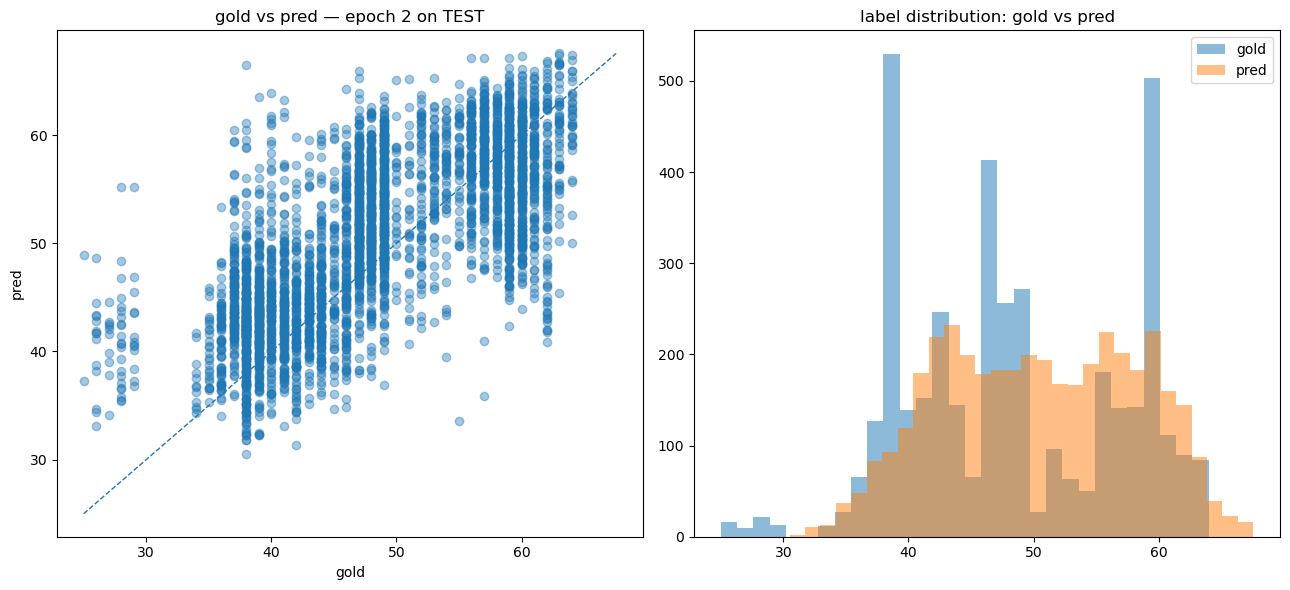

In [12]:
from utils_instance_train import plot_test_scatter

plot_test_scatter(run_dir, phase2_best)

## Inference spot-check

Five random TEST examples from the best epoch's saved predictions — a quick
gut-check that the numbers above correspond to sane per-instance behavior.

In [13]:
from utils_instance_train import spot_check

spot_check(run_dir, phase2_best, cfg.task_type)


INFERENCE SPOT-CHECK — 5 random TEST examples
  ParlaMint-HR_2018-02-07-0.u69740_25-150
     file=YOYZ7PwizwI  span=None–None
     gold=45.000   pred=49.229   |err|=4.229

  ParlaMint-HR_2022-01-27-0.u84831_1408-1546
     file=QAdDZZ-fs0M  span=None–None
     gold=44.000   pred=44.860   |err|=0.860

  ParlaMint-HR_2022-06-09-0.u114914_558-770
     file=MOvGADet3bU  span=None–None
     gold=36.000   pred=36.861   |err|=0.861

  ParlaMint-HR_2020-01-23-0.u183040_374-426
     file=S2arE590S-c  span=None–None
     gold=39.000   pred=40.728   |err|=1.728

  ParlaMint-HR_2021-03-04-0.u37719_141-156
     file=dmPzuXREvNw  span=None–None
     gold=43.000   pred=43.381   |err|=0.381



## Stage timing

Where the wall-clock went, stage by stage. Partial-run safe — it prints
whatever marks exist.

In [14]:
from utils_instance_train import print_stage_breakdown

mark("end script")
print_stage_breakdown()

stage timing (delta from previous mark)
------------------------
  literal start  00:00
  data prep      00:01
  model prep     02:36
  end phase 1    09:25
  end phase 2    10:59
  end script     00:02
------------------------
  TOTAL          23:02


## What's next

- Happy with a demo? Flip `run_mode` to `"full"` in `config.json` and hand it
  to the py runner — full runs don't belong in a notebook kernel.
- Different target: change `regression.target` in `config.json`
  (the menu is in the Targets cell above).
- Classification targets (gender, filled pauses) live in the twin:
  `31_train_instance_classification.ipynb`.